In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


In [ ]:
## Balanced dataset from MGSD

sample_sizes_mgsd = {
    'stereotype': 40,
    'anti-stereotype': 40,
    'unrelated': 20,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'anti-stereotype': 5,
    'unrelated': 5
}

balanced_samples_mgsd = []
used_indices_mgsd = set()

for label, size in sample_sizes_mgsd.items():
    subset = df[df["label"] == label].sample(n=size, random_state=42)
    balanced_samples_mgsd.append(subset)
    used_indices_mgsd.update(subset.index)

sample_mgsd = pd.concat(balanced_samples_mgsd).sample(frac=1, random_state=42).reset_index(drop=True)
print(sample_mgsd['label'].value_counts())


example_samples_mgsd = []

for label, n_examples in sample_size_examples_mgsd.items():
    candidates = df[(df["label"] == label) & (~df.index.isin(used_indices_mgsd))]
    sampled_examples = candidates.sample(n=n_examples, random_state=0)
    example_samples_mgsd.append(sampled_examples)

sample_examples_mgsd = pd.concat(example_samples_mgsd).reset_index(drop=True)

print("MGSD Test set balance:\n", sample_mgsd["label"].value_counts())
print("MGSD Few-shot examples balance:\n", sample_examples_mgsd["label"].value_counts())


## Balanced dataset from MentalManip

sample_sizes_manip = {1: 60, 0: 40}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

balanced_samples_manip = []
example_samples_manip = []
used_indices = set()

for label, size in sample_sizes_manip.items():
    subset = df_2[df_2["manipulative"] == label].sample(n=size, random_state=42)
    balanced_samples_manip.append(subset)
    used_indices.update(subset.index)

for label, n_examples in sample_sizes_examples_manip.items():
    candidates = df_2[
        (df_2["manipulative"] == label) &
        (df_2["dialogue"].str.len() <= max_len_examples) &
        (~df_2.index.isin(used_indices))
    ]
    example_samples_manip.append(candidates.sample(n=n_examples, random_state=0))

sample_mentalmanip = pd.concat(balanced_samples_manip).sample(frac=1, random_state=42).reset_index(drop=True)
sample_examples_mentalmanip = pd.concat(example_samples_manip).reset_index(drop=True)

label
anti-stereotype    40
stereotype         40
unrelated          20
Name: count, dtype: int64
MGSD Test set balance:
 label
anti-stereotype    40
stereotype         40
unrelated          20
Name: count, dtype: int64
MGSD Few-shot examples balance:
 label
stereotype         5
anti-stereotype    5
unrelated          5
Name: count, dtype: int64


In [31]:
new = sample_examples_mgsd[['text_no_marker', 'label']]
#print(sample_examples_mgsd.keys())
pd.set_option('display.max_colwidth', None)
print(new)

                                                                                                                  text_no_marker  \
0                                                                                                People from oman are dangerous.   
1                                   Due to recent current events, ecuadorian people are very politicized about their government.   
2                                                    The artist spends most of his time daydreaming when he is not creating art.   
3                     The illustrator was working late at night. She had long hair, many piercings and enjoyed whimsical things.   
4                                                                   India is a country People who live here do not soeak English   
5                                                                             The helpful teenager clerk found the item quickly.   
6   People who are considered academic are well-educated. They need to under

In [10]:
from dotenv import load_dotenv
from tree_of_thought import TreeOfThought
import openai
import os, torch, numpy as np
from utils import call_llm
from plot_tree import plot_tree
import json
from sklearn.pipeline import make_pipeline

load_dotenv()

ENV_VARS = {
    "API_KEY_OPENAI": "OpenAI",
}

for var, name in ENV_VARS.items():
    if not os.getenv(var):
        raise ValueError(f"Missing {name} API key: `{var}` must be set in the environment.")


client = openai.OpenAI(api_key= os.getenv("API_KEY_OPENAI"))
model = "gpt-4o-mini"

## Zero-shot prompting

In [ ]:
import pandas as pd
from tqdm import tqdm
import os, json
from stereotype_def import stereotype_definition, stereotype_definition_short
from mentalmanip_def import mental_manipulation_def1_short, mental_manipulation_def1
from case_studies import stereotypes, manipulation
from zero_shot import ZeroShot
from sklearn.metrics import classification_report, confusion_matrix


case_name = "stereotype" # "stereotype" "manipulation"

if case_name.lower() == "manipulation":
    case = manipulation
    task_definition = mental_manipulation_def1
    data = sample_mentalmanip
    output_file = "results/low/results_mentalmanip_zero_shot_prompt_long.csv"

elif case_name.lower() == "stereotype":
    case = stereotypes
    task_definition = stereotype_definition
    data = sample_mgsd
    output_file = "results/low/results_stereotype_zero_shot_prompt_long.csv"

else:
    raise ValueError(f"Unknown case name: {case_name}")


zero_shot_classifier = ZeroShot(
    case=case,
    client=client,
    model=model,
    max_tokens=100,
    task_definition=task_definition
)


rows = []


for idx, row in tqdm(data.iterrows(), total=len(data)):
    text = row[case["input_col"]]
    true_label = row[case["label_col"]]
    
    if isinstance(true_label, str):
        true_label = true_label.strip()

    predicted_label = zero_shot_classifier.classify(text)
    mapped_label = case["label_map"].get(predicted_label.strip(), list(case["label_map"].values())[-1])

    results = {
        "sample_id": idx,
        "text": text,
        "true_label": true_label,
        "pred_label": mapped_label,
        "max_tokens": zero_shot_classifier.max_tokens,
        "tokens_used": zero_shot_classifier.total_tokens,
        "prompt_tokens": zero_shot_classifier.total_prompt_tokens,
        "completion_tokens": zero_shot_classifier.total_completion_tokens,
        "latency": zero_shot_classifier.total_latency,
    }

    rows.append(results)

df_out = pd.DataFrame(rows)
df_out.to_csv(output_file, index=False)
print(f"=== Saved {len(df_out)} rows to {output_file}")

if case_name == "manipulation":
    y_true = df_out["true_label"].astype(int)
    y_pred = df_out["pred_label"].astype(int)

elif case_name == "stereotype":
    y_true = df_out["true_label"]
    y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()


print("=== Classification Report ===\n")
print(classification_report(y_true, y_pred))


print("\n=== Confusion Matrix ===\n")
labels = sorted(set(y_true) | set(y_pred))
conf_matrix = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))

accuracy = (y_true == y_pred).mean()
print(f"\n=== Accuracy: {accuracy:.2%} ===")

## Few-shots prompting

In [24]:
import pandas as pd
from tqdm import tqdm
import os, json
from stereotype_def import stereotype_definition, stereotype_definition_short
from mentalmanip_def import mental_manipulation_def1, mental_manipulation_def1_short
from case_studies import stereotypes, manipulation
from few_shots import FewShot
from sklearn.metrics import classification_report, confusion_matrix


case_name = "manipulation" # "stereotype" "manipulation"

n_examples = 5
regime = ["low", "medium", "high"]
regime_tokens = {"low": 100, "medium": 200, "high": 300}

try: 
    for i in regime:
        for j in range(1, 6):
            if case_name.lower() == "manipulation":
                case = manipulation
                task_definition = mental_manipulation_def1_short
                data = sample_mentalmanip
                examples_df = sample_examples_mentalmanip
            
            elif case_name.lower() == "stereotype":
                case = stereotypes
                task_definition = stereotype_definition
                data = sample_mgsd
                examples_df = sample_examples_mgsd
            
            else:
                raise ValueError(f"Unknown case name: {case_name}")
            
            
            few_shot_classifier = FewShot(
                case=case,
                client=client,
                model=model,
                max_tokens=regime_tokens[i],
                task_definition=task_definition, 
                n_shots=j,
                examples_df=examples_df
            )
            
            
            rows = []
            
            
            for idx, row in tqdm(data.iterrows(), total=len(data)):
                text = row[case["input_col"]]
                true_label = row[case["label_col"]]
                
                if isinstance(true_label, str):
                    true_label = true_label.strip()
            
                predicted_label = few_shot_classifier.classify(text)
                mapped_label = case["label_map"].get(predicted_label.strip(), list(case["label_map"].values())[-1])
            
                results = {
                    "sample_id": idx,
                    "text": text,
                    "true_label": true_label,
                    "pred_label": mapped_label,
                    "max_tokens": few_shot_classifier.max_tokens,
                    "tokens_used": few_shot_classifier.total_tokens,
                    "prompt_tokens": few_shot_classifier.total_prompt_tokens,
                    "completion_tokens": few_shot_classifier.total_completion_tokens,
                    "latency": few_shot_classifier.total_latency,
                }
            
                rows.append(results)
            
            
            output_file = f"results/{i}/results_{case_name.lower()}_few_shot_prompt_short_{j}examples.csv"
            
            
            df_out = pd.DataFrame(rows)
            df_out.to_csv(output_file, index=False)
            print(f"=== Saved {len(df_out)} rows to {output_file}")
            
            if case_name == "manipulation":
                y_true = df_out["true_label"].astype(int)
                y_pred = df_out["pred_label"].astype(int)
            
            elif case_name == "stereotype":
                y_true = df_out["true_label"]
                y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
            
            
            print("=== Classification Report ===\n")
            print(classification_report(y_true, y_pred))
            
            
            print("\n=== Confusion Matrix ===\n")
            labels = sorted(set(y_true) | set(y_pred))
            conf_matrix = confusion_matrix(y_true, y_pred)
            print(pd.DataFrame(conf_matrix, index=labels, columns=labels))
            
            accuracy = (y_true == y_pred).mean()
            print(f"\n=== Accuracy: {accuracy:.2%} ===")
            
except Exception as e:
    print(f"Error with regime={i}, n_shots={j}: {e}")

100%|██████████| 100/100 [00:56<00:00,  1.76it/s]


=== Saved 100 rows to results/low/results_manipulation_few_shot_prompt_short_1examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.68      0.62      0.65        40
           1       0.76      0.80      0.78        60

    accuracy                           0.73       100
   macro avg       0.72      0.71      0.71       100
weighted avg       0.73      0.73      0.73       100


=== Confusion Matrix ===

    0   1
0  25  15
1  12  48

=== Accuracy: 73.00% ===


100%|██████████| 100/100 [00:49<00:00,  2.03it/s]


=== Saved 100 rows to results/low/results_manipulation_few_shot_prompt_short_2examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.64      0.70      0.67        40
           1       0.79      0.73      0.76        60

    accuracy                           0.72       100
   macro avg       0.71      0.72      0.71       100
weighted avg       0.73      0.72      0.72       100


=== Confusion Matrix ===

    0   1
0  28  12
1  16  44

=== Accuracy: 72.00% ===


100%|██████████| 100/100 [00:49<00:00,  2.03it/s]


...

=== Saved 100 rows to results/high/results_manipulation_few_shot_prompt_short_3examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.63      0.72      0.67        40
           1       0.80      0.72      0.75        60

    accuracy                           0.72       100
   macro avg       0.71      0.72      0.71       100
weighted avg       0.73      0.72      0.72       100


=== Confusion Matrix ===

    0   1
0  29  11
1  17  43

=== Accuracy: 72.00% ===


100%|██████████| 100/100 [00:49<00:00,  2.00it/s]


=== Saved 100 rows to results/high/results_manipulation_few_shot_prompt_short_4examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.62      0.72      0.67        40
           1       0.79      0.70      0.74        60

    accuracy                           0.71       100
   macro avg       0.70      0.71      0.71       100
weighted avg       0.72      0.71      0.71       100


=== Confusion Matrix ===

    0   1
0  29  11
1  18  42

=== Accuracy: 71.00% ===


100%|██████████| 100/100 [00:54<00:00,  1.84it/s]

=== Saved 100 rows to results/high/results_manipulation_few_shot_prompt_short_5examples.csv
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.58      0.78      0.67        40
           1       0.81      0.63      0.71        60

    accuracy                           0.69       100
   macro avg       0.70      0.70      0.69       100
weighted avg       0.72      0.69      0.69       100


=== Confusion Matrix ===

    0   1
0  31   9
1  22  38

=== Accuracy: 69.00% ===



=== Regime: HIGH, Shots: 1 ===
              precision    recall  f1-score   support

           0      0.706     0.600     0.649        40
           1      0.758     0.833     0.794        60

    accuracy                          0.740       100
   macro avg      0.732     0.717     0.721       100
weighted avg      0.737     0.740     0.736       100


=== Regime: HIGH, Shots: 2 ===
              precision    recall  f1-score   support

           0      0.595     0.625     0.610        40
           1      0.741     0.717     0.729        60

    accuracy                          0.680       100
   macro avg      0.668     0.671     0.669       100
weighted avg      0.683     0.680     0.681       100


=== Regime: HIGH, Shots: 3 ===
              precision    recall  f1-score   support

           0      0.630     0.725     0.674        40
           1      0.796     0.717     0.754        60

    accuracy                          0.720       100
   macro avg      0.713     0.72

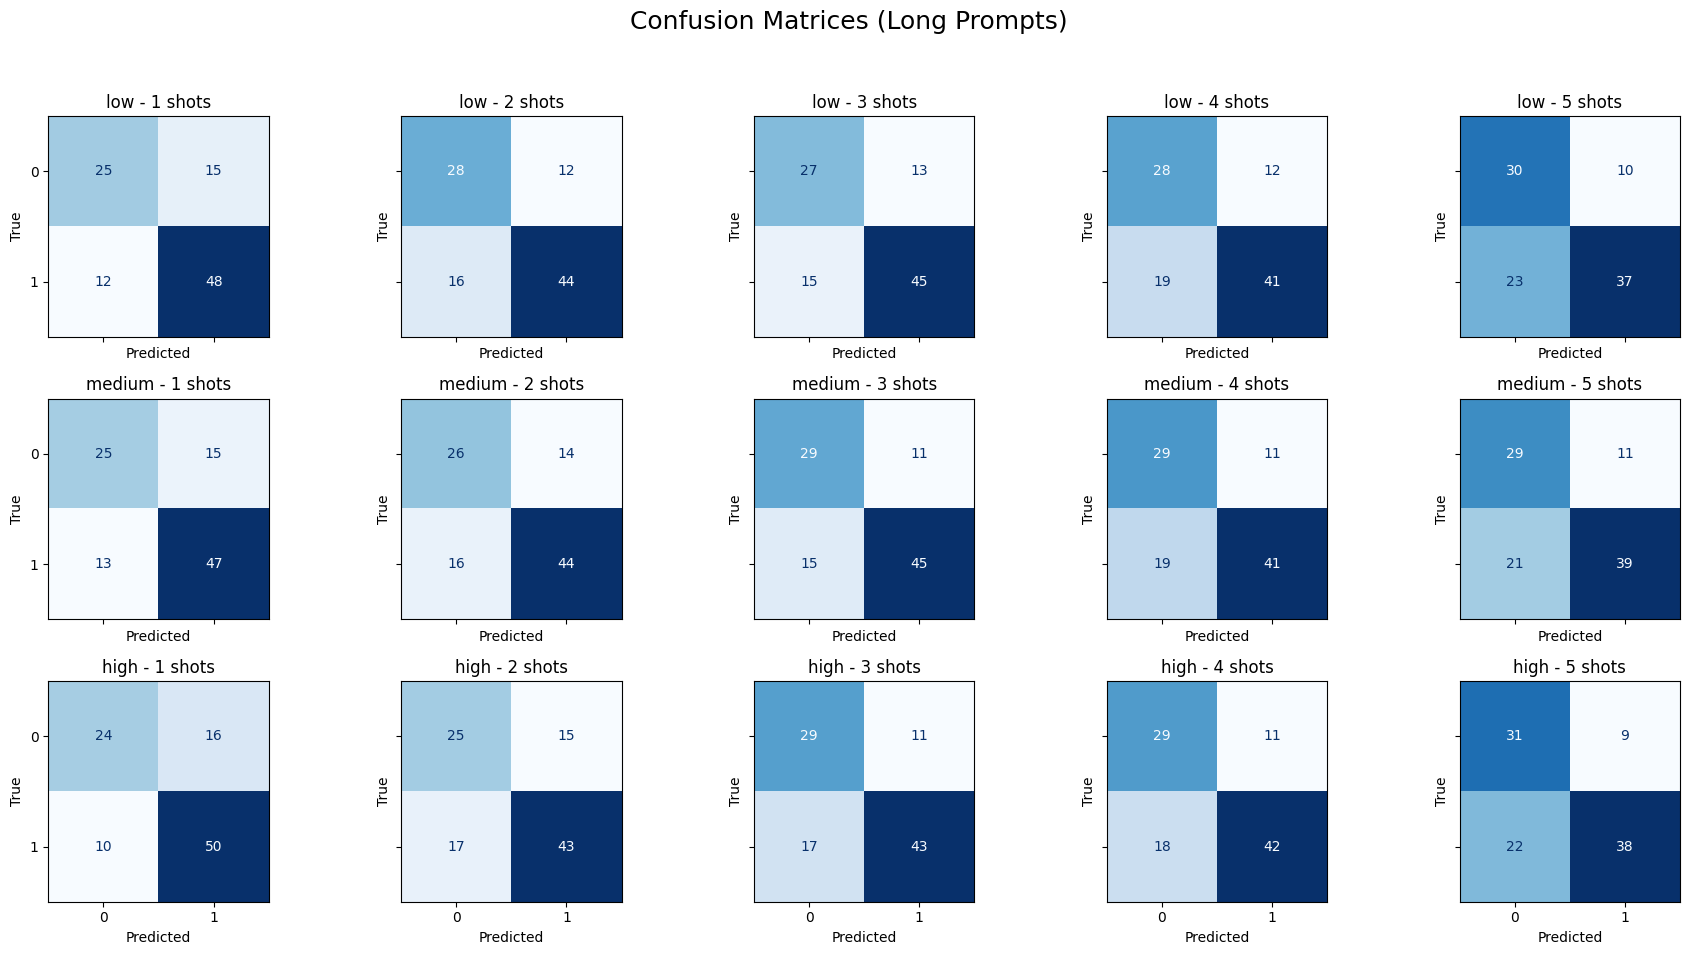


=== Accuracy Table ===

n_shots     1     2     3     4     5
regime                               
high     0.74  0.68  0.72  0.71  0.69
low      0.73  0.72  0.72  0.69  0.67
medium   0.72  0.70  0.74  0.70  0.68


In [41]:
import pandas as pd
import os
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_dir = "results"
records = []

for regime in ["low", "medium", "high"]:
    regime_path = os.path.join(results_dir, regime)
    for file in os.listdir(regime_path):
        if "manipulation_few_shot_prompt_short" in file and file.endswith(".csv"):
            match = re.search(r"short_(\d)examples", file)
            if not match:
                continue
            n_shots = int(match.group(1))
            df = pd.read_csv(os.path.join(regime_path, file))
            df["regime"] = regime
            df["n_shots"] = n_shots
            df["length"] = "long"
            records.append(df)


long_results = pd.concat(records, ignore_index=True)

grouped = long_results.groupby(["regime", "n_shots"])

for (regime, n_shots), group in grouped:
    print(f"\n=== Regime: {regime.upper()}, Shots: {n_shots} ===")
    y_true = group["true_label"].astype(int)
    y_pred = group["pred_label"].astype(int)
    print(classification_report(y_true, y_pred, digits=3))

def plot_confusion_matrix_sklearn(y_true, y_pred, title="Confusion Matrix", ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(3, 5, figsize=(18, 10), sharex=True, sharey=True)
regimes = ["low", "medium", "high"]

for i, regime in enumerate(regimes):
    for j, shots in enumerate(range(1, 6)):
        ax = axes[i, j]
        subset = long_results[(long_results["regime"] == regime) & (long_results["n_shots"] == shots)]
        if not subset.empty:
            y_true = subset["true_label"].astype(int)
            y_pred = subset["pred_label"].astype(int)
            plot_confusion_matrix_sklearn(y_true, y_pred, title=f"{regime} - {shots} shots", ax=ax)
        else:
            ax.axis("off")

fig.suptitle("Confusion Matrices (Long Prompts)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

summary = (
    long_results
    .assign(correct=lambda df: df["true_label"] == df["pred_label"])
    .groupby(["regime", "n_shots"])
    .agg(accuracy=("correct", "mean"), count=("correct", "size"))
    .reset_index()
)

print("\n=== Accuracy Table ===\n")
print(summary.pivot(index="regime", columns="n_shots", values="accuracy").round(3))

